# **Los Angeles Clippers Dataset BI Analysis**
#### Prepared by Oluwaseyi Caleb Folorunso

### Objective/Overview
* Understand fan purchase behavior across game days accounted for in the dataset.
* Identify major revenue drivers among store types and business verticals.
* Provide recommendations for improving overall store performance.

### Data Loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re

In [ ]:
clipper_ds = "LA Clippers Fall 2025 Business Insights Data Challenge Dataset.xlsx"

xls = pd.ExcelFile(clipper_ds)
print(xls.sheet_names)

['Retail+F&B 4.24', 'Retail+F&B 4.26', 'Retail+F&B 5.1', 'EntryScans', 'CustomerIDs', 'StoreEntries 4.24', 'StoreEntries 4.26', 'StoreEntries 5.1', 'Arena Pricing Map', 'StoreNames']


Primarily, I will be working with the four listed datasets below:
* Retail+F&B (**ALL**): Transaction-level sales
* StoreEntries (**ALL**): Foot traffic logs
* CustomerIDs: Maps NBAId → CustomerAccount
* StoreNames: Maps store checkpoints to store numbers & store types

### Standardization & Cleaning

As aforementioned “Retail+F&B” sheet contains order-line item level purchases at the Intuit Dome retail shops from each of the three playoff game nights accounted for.
\
First, I standardized column names and date formats and merged them into one large dataset: **retail_all**, now containing **every** documented purchase transaction made by fans at the retail and food & beverage stores over the course of the three games. This also includes timestamps, amounts, store IDs and customer IDs.

In [ ]:
# Standardized and concatenated the Retail F&B Sheets into one DataFrame

retail_sheets = ['Retail+F&B 4.24', 'Retail+F&B 4.26', 'Retail+F&B 5.1']
retail_dfs = []

for sheet in retail_sheets:
    df = pd.read_excel(xls, sheet_name = sheet)
    df.columns = df.columns.str.strip()  # To remove spaces
    df['TransactionDateTime'] = pd.to_datetime(df['TransactionDateTime'], errors='coerce') # Error handling for datetime conversion
    df['CustomerAccount'] = df['CustomerAccount'].astype(str).str.strip().replace({'nan': None})
    retail_dfs.append(df)

# Combine into one DataFrame
retail_all = pd.concat(retail_dfs, ignore_index=True)
retail_all.head()

,TransactionId,CustomerAccount,ItemId,ProductName,Category,BusinessVertical,Quantity,NetAmount,DiscountAmount,Store,TransactionDateTime
0,138871520250425,C000323270,Z0001,Open Water,Markets & Clubs,Food And Beverage,1,0.0,7.0,\t3D004,2025-04-24 19:04:05.323
1,138129420250425,C000964128,Z0001,Open Water,Markets & Clubs,Food And Beverage,1,0.0,7.0,\t7D004,2025-04-24 17:39:24.069
2,139220820250425,C000417769,Z0001,Open Water,Markets & Clubs,Food And Beverage,1,0.0,7.0,\t7F012,2025-04-24 20:07:43.546
3,139482820250425,C000969671,Z0001,Open Water,Markets & Clubs,Food And Beverage,1,0.0,7.0,\t7A022,2025-04-24 20:33:01.837
4,141900920250427,C000533271,Z0001,Open Water,Markets & Clubs,Food And Beverage,1,0.0,7.0,\t3B032,2025-04-24 20:24:09.287


Similarly, I gathered the foot traffic data (**StoreEntries**) and combined them. Also cleaned the timestamps for smoother analysis. \
**Every** attendee who entered a store area in the given window (whether or not they made any purchases) is accounted for in one DataFrame.

In [ ]:
# Similar standardization of the Store Entry Sheets into one DataFrame

store_sheets = ['StoreEntries 4.24', 'StoreEntries 4.26', 'StoreEntries 5.1']
store_dfs = []

for sheet in store_sheets:
    df = pd.read_excel(xls, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    df['StoreEnterDateTime'] = pd.to_datetime(df['StoreEnterDateTime'], errors='coerce')
    store_dfs.append(df)

store_entries = pd.concat(store_dfs, ignore_index=True)
store_entries.head()

,eventid,StoreEnterDate,StoreEnterDateTime,NBAId,CheckpointName,accessmethodname
0,b088781d-fafa-4139-8836-ce5a8a121519,2025-04-24,2025-04-24 17:56:50.190,d58f50fc-3c92-419e-a541-0052e266baa7,704 Pick & Roll,BIOMETRIC
1,3cd2a794-a175-423d-9f20-7f193df5db76,2025-04-24,2025-04-24 15:52:59.050,a668d618-8f1f-40b9-94be-5f1887b9bb70,Flagship,BIOMETRIC
2,267d7b64-19ac-47e0-8776-5dbe0f8c47e3,2025-04-24,2025-04-24 15:51:53.967,a668d618-8f1f-40b9-94be-5f1887b9bb70,Flagship,BIOMETRIC
3,7dd96910-af28-47cf-8302-2e936200281a,2025-04-24,2025-04-24 18:26:10.567,ed0efa6f-eb1a-4043-a87f-02157edff0a9,718 The Wall! Store,BIOMETRIC
4,3225a521-9ab4-4065-9fac-36aabe8e0af7,2025-04-24,2025-04-24 20:16:55.510,a2af6980-58bb-4d61-b06f-d5fd43442711,D'USSÃ‰ Cognac Club,BIOMETRIC


**CustomerIDs** sheet maps *NBAId* → *CustomerAccount*, I load it for reference

In [ ]:
# Load CustomerIDs for reference only (not merging)
customer = pd.read_excel(xls, sheet_name='CustomerIDs')
customer.columns = customer.columns.str.strip()
customer['NBAId'] = customer['NBAId'].astype(str).str.strip()
customer['CustomerAccount'] = customer['CustomerAccount'].astype(str).str.strip()

print(f"CustomerIDs shape: {customer.shape}")
print(customer.head())

CustomerIDs shape: (38676, 4)
         NBAId CustomerAccount  DistanceToIntuitDome      AppCreatedDatetime
0  10000000001      C000953337                 120.0 2025-04-14 17:16:13.350
1  10000000002      C001005010                   5.0 2025-05-01 16:12:28.347
2  10000000003      C000994137                   5.0 2025-04-28 02:40:13.563
3  10000000004      C000935556                  30.0 2025-04-08 21:22:37.960
4  10000000004      C000935556                  30.0 2025-04-08 21:22:37.960


### Store Mapping/Integration

The next step is to map the store entries and retail transactions using the **StoreNames** sheet as a bridge table. The reasons being  

*   *Store* in **retail_all** = *Store Number* in **StoreNames**
*   *CheckpointName* in **store_entries** = *Checkpoint Name* in **StoreNames**

In [ ]:
store_names = pd.read_excel(xls, sheet_name='StoreNames')
store_names.columns = store_names.columns.str.strip()

# Convert Store to string for safe joins
retail_all['Store'] = retail_all['Store'].astype(str).str.strip()
store_names['Store Number'] = store_names['Store Number'].astype(str).str.strip()
store_names['Checkpoint Name'] = store_names['Checkpoint Name'].astype(str).str.strip()
store_entries['CheckpointName'] = store_entries['CheckpointName'].astype(str).str.strip()

# Left join: keep all store entry rows, add store info
store_entries_mapped = store_entries.merge(
    store_names[['Store Number', 'Store Name', 'Store Type', 'Checkpoint Name']],
    left_on='CheckpointName',
    right_on='Checkpoint Name',
    how='left'
)

print(f"Rows: {store_entries_mapped.shape[0]:,}")
print(store_entries_mapped[['CheckpointName', 'Store Number', 'Store Name']].head(10))

Rows: 49,223
         CheckpointName Store Number           Store Name
0       704 Pick & Roll        7D004      704 Pick & Roll
1              Flagship        3P101             Flagship
2              Flagship        3P101             Flagship
3   718 The Wall! Store        7A018  718 The Wall! Store
4   D'USSÃ‰ Cognac Club          NaN                  NaN
5              Flagship        3P101             Flagship
6       704 Pick & Roll        7D004      704 Pick & Roll
7       Club Grey Goose          NaN                  NaN
8  308 Fast Break & Bar        3E008       308 Fast Break
9         Clips Shop 3B        3B028       328 Clips Shop


Each store entry now has a Store Number and Store Name (Store Type, as well). \
Below I checked the match rate just to ensure a good enough mapping.

In [ ]:
matches = store_entries_mapped['Store Number'].notna().sum()
total = len(store_entries_mapped)
print(f"\nMatched {matches:,} out of {total:,} store entries ({matches/total:.1%} match rate).")


Matched 44,135 out of 49,223 store entries (89.7% match rate).


About 90% of the store entries actually found a match in *StoreNames*, which I feel is high enough for this analysis so I will go ahead and merge with the retail data.
\
\
Now I can map **retail_all** using the Store --> Store Number relationship. This enriches the **retail_all** DataFrame by providing location context that will come in handy.

In [ ]:
retail_mapped = retail_all.merge(
    store_names[['Store Number', 'Checkpoint Name', 'Store Name', 'Store Type']],
    left_on='Store',
    right_on='Store Number',
    how='left'
)

retail_mapped.head()

,TransactionId,CustomerAccount,ItemId,ProductName,Category,BusinessVertical,Quantity,NetAmount,DiscountAmount,Store,TransactionDateTime,Store Number,Checkpoint Name,Store Name,Store Type
0,138871520250425,C000323270,Z0001,Open Water,Markets & Clubs,Food And Beverage,1,0.0,7.0,3D004,2025-04-24 19:04:05.323,3D004,304 Pick & Roll,304 Pick & Roll,Concessions & Retail
1,138129420250425,C000964128,Z0001,Open Water,Markets & Clubs,Food And Beverage,1,0.0,7.0,7D004,2025-04-24 17:39:24.069,7D004,704 Pick & Roll,704 Pick & Roll,Concessions & Retail
2,139220820250425,C000417769,Z0001,Open Water,Markets & Clubs,Food And Beverage,1,0.0,7.0,7F012,2025-04-24 20:07:43.546,7F012,712 Fast Break,712 Fast Break,Concessions & Retail
3,139482820250425,C000969671,Z0001,Open Water,Markets & Clubs,Food And Beverage,1,0.0,7.0,7A022,2025-04-24 20:33:01.837,7A022,722 Fast Break,722 Fast Break,Concessions & Retail
4,141900920250427,C000533271,Z0001,Open Water,Markets & Clubs,Food And Beverage,1,0.0,7.0,3B032,2025-04-24 20:24:09.287,3B032,332 Pick & Roll,332 Pick & Roll,Concessions & Retail


As each purchase now has its corresponding store and location info, I will group the transactions by hour of day (24-hour notation) and store, showing transaction patterns through which I can learn when each store is busiest and not.
\
\
Using the transaction data, I will then visualize the time-based performace profile for each store.


         Checkpoint Name  Hour_Peak  TransactionCount_Peak  Hour_Low  \
0        302 Pick & Roll         20                    249        12   
1        304 Pick & Roll         18                    358        21   
2         305 Fast Break         20                    222        13   
3   308 Fast Break & Bar         18                    269        21   
4        311 Pick & Roll         18                    313        11   
5        315 Pick & Roll         18                    510        21   
6               315B Bar         18                     52        17   
7        319 Pick & Roll         18                    359        21   
8        322 Pick & Roll         20                    194        21   
9         323 Fast Break         20                    137        21   
10  326 Fast Break & Bar         20                    291        12   
11        329 Fast Break         20                    167        13   
12       331 Pick & Roll         20                    260      

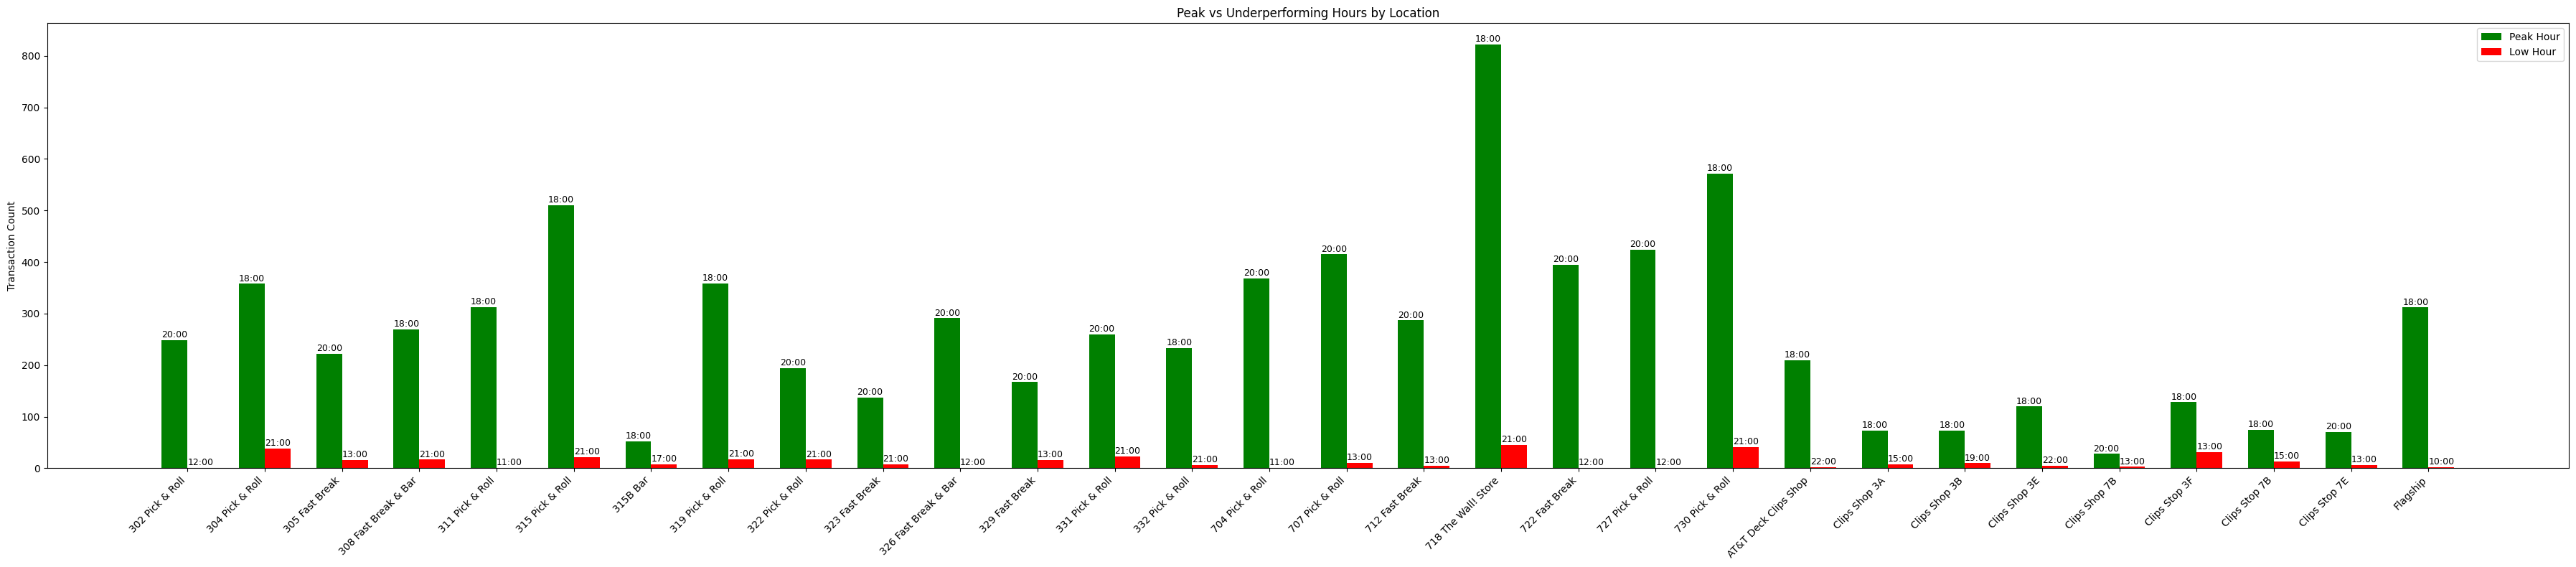

In [ ]:
# Extract hour from timestamp
retail_mapped['Hour'] = retail_mapped['TransactionDateTime'].dt.hour

# Group by location and hour
hourly_counts = retail_mapped.groupby(['Checkpoint Name', 'Hour'])['TransactionId'].nunique().reset_index()
hourly_counts.rename(columns={'TransactionId': 'TransactionCount'}, inplace=True)

# Identify peak and low hours per location
peak_hours = hourly_counts.loc[hourly_counts.groupby('Checkpoint Name')['TransactionCount'].idxmax()]
low_hours = hourly_counts.loc[hourly_counts.groupby('Checkpoint Name')['TransactionCount'].idxmin()]

# Merge for plotting
summary = pd.merge(
    peak_hours[['Checkpoint Name', 'Hour', 'TransactionCount']],
    low_hours[['Checkpoint Name', 'Hour', 'TransactionCount']],
    on='Checkpoint Name',
    suffixes=('_Peak', '_Low')
)
print(summary)

# Plotting
fig, ax = plt.subplots(figsize=(36,8))
x = np.arange(len(summary)) * 1.2

# Bars
bars_peak = ax.bar(x, summary['TransactionCount_Peak'], width=0.4, label='Peak Hour', color='green', align='center')
bars_low = ax.bar([i + 0.4 for i in x], summary['TransactionCount_Low'], width=0.4, label='Low Hour', color='red', align='center')

# Labeling
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(summary['Checkpoint Name'], rotation=45, ha='right')
ax.set_ylabel('Transaction Count')
ax.set_title('Peak vs Underperforming Hours by Location')
ax.legend()

# Annotate hours on bars
for i, bar in enumerate(bars_peak):
    hour = summary.iloc[i]['Hour_Peak']
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{hour}:00', ha='center', va='bottom', fontsize=9)

for i, bar in enumerate(bars_low):
    hour = summary.iloc[i]['Hour_Low']
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{hour}:00', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

*Figure 1*

### 💡 **Insight 1**


*   Across all the stores, transaction activity is at its **highest** between 6PM and 8PM PT. Afterwards, there is a significant drop by and around 9PM.

The games on the 24th of April and 1st of May (Games 3 and 6 of the series respectively) started around 7PM PT, this would suggest that fans were making most of their purchases prior to tip-off and around or during halftime.\
\
According to https://www.basketball-reference.com/playoffs/NBA_2025_games.html, both games lasted roughly 2 and a half hours, this explains the plummet by 9PM as stores garnered the least amount of traffic towards the end of the night.

Game 4 (April 26th) began at 3PM PT which likely explains some of the recorded data (although pits) coming in much earlier in the day around 12PM and 1PM.



Furthermore, my next business step is to compare the total sales by store type (Concessions vs. Retail).

In [ ]:
# Compute total sales per store type
sales_by_type = retail_mapped.groupby('Store Type')['NetAmount'].sum().reset_index()

# Compute average sales per transaction
avg_spend_by_type = retail_mapped.groupby('Store Type')['NetAmount'].mean().reset_index()

# Combine both for clarity
sales_summary = sales_by_type.merge(avg_spend_by_type, on='Store Type', suffixes=('_Total', '_AvgPerTransaction'))

print(sales_summary)

             Store Type  NetAmount_Total  NetAmount_AvgPerTransaction
0           Concessions         40272.33                    15.055077
1  Concessions & Retail        691902.16                    13.920172
2                Retail        423616.25                    53.024941


 As the Store Type groups stores broadly (Concessions & Retail vs. Concessions/Retail). This ambiguity was not ideal for making a good judgement as to what business impacted the transaction revenue the most under the *Concessions & Retail* store type. \
 I decided to distinguish the "Food And Beverage" stores from the "Retail" stores using the *BusinessVertical* information given in the **Retail+F&B** sheets in order to enrich my analysis.

In [ ]:
# Since retail_all['Store'] ↔ store_names['Store Number'], merge

retail_enriched = retail_all.merge(
    store_names[['Store Number', 'Store Name', 'Store Type']],
    left_on='Store',
    right_on='Store Number',
    how='left'
)

print(retail_enriched[['Store', 'Store Name', 'Store Type', 'BusinessVertical']].head())

   Store       Store Name            Store Type   BusinessVertical
0  3D004  304 Pick & Roll  Concessions & Retail  Food And Beverage
1  7D004  704 Pick & Roll  Concessions & Retail  Food And Beverage
2  7F012   712 Fast Break  Concessions & Retail  Food And Beverage
3  7A022   722 Fast Break  Concessions & Retail  Food And Beverage
4  3B032  332 Pick & Roll  Concessions & Retail  Food And Beverage


In [ ]:
# Isolate the Concessions & Retail stores

concessions_df = retail_mapped[retail_mapped['Store Type'].str.strip() == 'Concessions & Retail']

# Now that I have both Store Type and Business Vertical, I can group by the latter

sales_by_vertical = (
    concessions_df.groupby('BusinessVertical')['NetAmount']
    .sum()
    .reset_index(name='TotalSales')
    .sort_values('TotalSales', ascending=False)
)

total_sales = sales_by_vertical['TotalSales'].sum()
sales_by_vertical['SalesShare(%)'] = (sales_by_vertical['TotalSales'] / total_sales) * 100

print(sales_by_vertical)

    BusinessVertical  TotalSales  SalesShare(%)
0  Food And Beverage   685716.00      99.105920
1             Retail     5313.25       0.767919
2      Service Items      872.91       0.126161


/tmp/ipython-input-3846875921.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_summary, x='Store Type', y='NetAmount_Total', ax=axes[0], palette='viridis')
/tmp/ipython-input-3846875921.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_vertical, x='BusinessVertical', y='TotalSales', ax=axes[1], palette='bright')


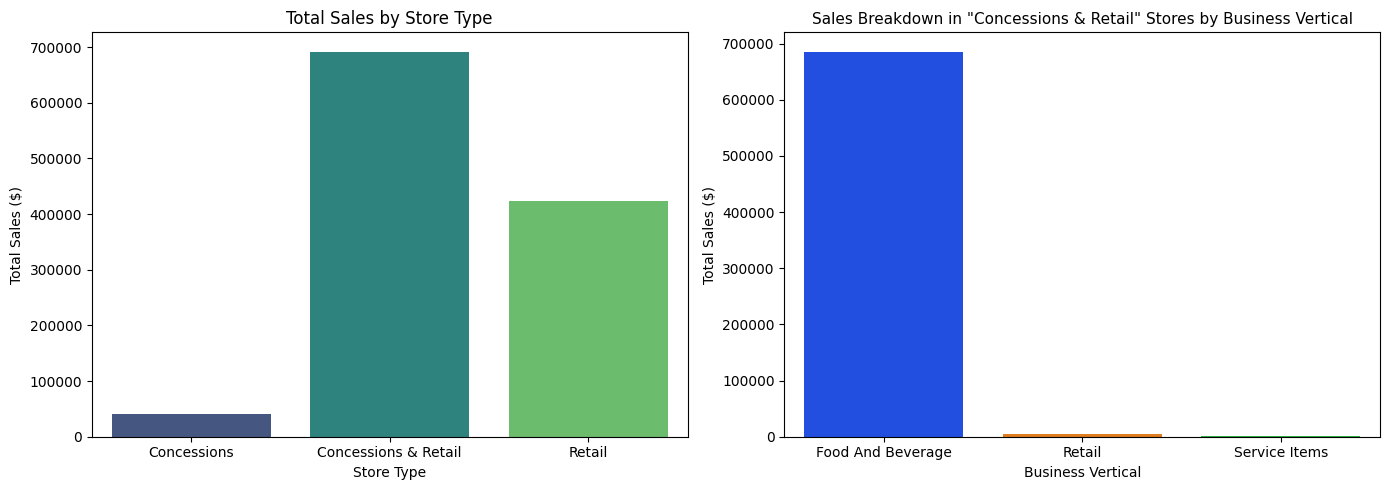

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left chart----
sns.barplot(data=sales_summary, x='Store Type', y='NetAmount_Total', ax=axes[0], palette='viridis')
axes[0].set_title('Total Sales by Store Type')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_xlabel('Store Type')

# ---- Right chart----
sns.barplot(data=sales_by_vertical, x='BusinessVertical', y='TotalSales', ax=axes[1], palette='bright')

axes[1].set_title('Sales Breakdown in "Concessions & Retail" Stores by Business Vertical', fontsize=11)
axes[1].set_ylabel('Total Sales ($)')
axes[1].set_xlabel('Business Vertical')

plt.tight_layout()
plt.show()

*Figure 2*

###💡 **Insight 2**


*   Food & Beverage outlets generate a *rather* significantly higher total revenue and per-customer spending than retail stores.

Within the *Concessions & Retail* stores, the Food And Beverage vertical contributes 99% of total sales, compared to less than 1% from merchandise retail. This highlights that in mixed-format stores, food and drink purchases dominate customer spending behavior. Although, in total, retail stores on their own garner an impressive ~429,000 dollars, the concessions business still comes out on top at ~726,000 dollars in total → about 1.7% better.

### **Business Recommendation**

Placing focus on enhancing F&B availability and conversion during the peak hours, especially before and around halftime.
Businesses could consider introducing F&B mobile ordering or pre-halftime bundle deals (even pre-game loyalty deals) to take full advantage of the surge in demand while also reducing queue times. \
Another similar recommendation would be introducing post-game retail promotions like discounted merchandise after the 4th quarter. This could help address low transaction volumes in underperforming hours.